# ***FAKE NEWS DETECTION USING MACHINE LEARNING AND DEEP LEARNING MODELS***

## IMPORT LIBRARIES

In [1]:
#install pre-requisites
!pip install seaborn

In [2]:
#libraries
import re
import string
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
import PIL.Image
from collections import Counter

import nltk
from nltk import pos_tag
from nltk.corpus import wordnet, stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.tokenize import sent_tokenize, word_tokenize

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, confusion_matrix

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Embedding,Bidirectional, LSTM
from tensorflow.keras.utils import plot_model

In [3]:
#download
nltk.download('words')
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('maxent_ne_chunker')

[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker.zip.


True

In [4]:
#settings

# Set NumPy print options to display the full array without truncation
np.set_printoptions(threshold=np.inf)

# Set Pandas option to display all rows in DataFrames without truncation
pd.set_option('display.max_rows', None)

# Set Pandas option to display all columns in DataFrames without truncation
pd.set_option('display.max_columns', None)

## LOAD THE DATASETS

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
df_true = pd.read_csv('/content/drive/MyDrive/dissertation/dataset/True.csv')

In [7]:
df_fake = pd.read_csv('/content/drive/MyDrive/dissertation/dataset/Fake.csv')

## ANALYSING THE DATASET

### TRUE DATA

In [8]:
df_true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [9]:
df_true.describe()

,title,text,subject,date
count,21417,21417,21417,21417
unique,20826,21192,2,716
top,Factbox: Trump fills top jobs for his administ...,(Reuters) - Highlights for U.S. President Dona...,politicsNews,"December 20, 2017"
freq,14,8,11272,182


In [10]:
df_true.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    21417 non-null  object
 1   text     21417 non-null  object
 2   subject  21417 non-null  object
 3   date     21417 non-null  object
dtypes: object(4)
memory usage: 669.4+ KB


In [11]:
# Subject value count
df_true['subject'].value_counts()

subject
politicsNews    11272
worldnews       10145
Name: count, dtype: int64

<ipython-input-12-368877f8db1b>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='subject', data=True_News, width=0.4, palette='deep')


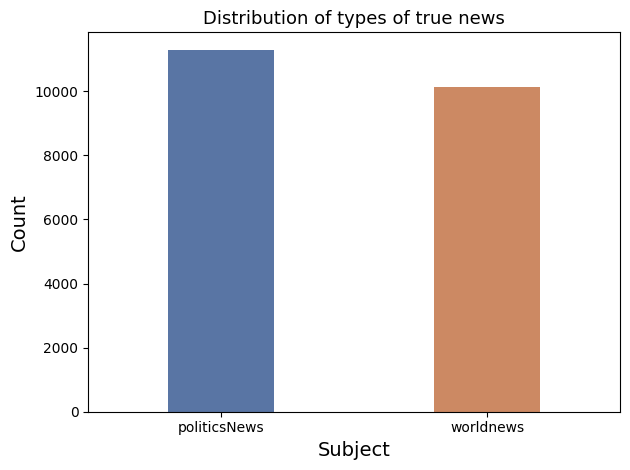

In [12]:
# visualising the subject column
True_News = df_true
sns.countplot(x='subject', data=True_News, width=0.4, palette='deep')
plt.xlabel('Subject', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('Distribution of types of true news', fontsize=13)
plt.tight_layout()  # to ensure proper spacing
plt.savefig("True_subjects.jpeg")
plt.show()

In [13]:
# Date value count
df_true.date.value_counts()

date
December 20, 2017      182
December 6, 2017       166
November 30, 2017      162
November 9, 2017       158
October 13, 2017       155
September 21, 2017     153
December 21, 2017      151
September 6, 2017      151
September 7, 2017      149
September 22, 2017     146
October 19, 2017       145
November 8, 2017       143
September 12, 2017     143
October 18, 2017       142
October 26, 2017       142
September 15, 2017     141
October 16, 2017       141
December 7, 2017       140
October 24, 2017       139
October 12, 2017       137
September 26, 2017     136
October 25, 2017       136
November 29, 2017      134
December 8, 2017       134
December 14, 2017      133
September 14, 2017     131
December 5, 2017       131
November 21, 2017      129
November 2, 2017       128
November 1, 2017       127
September 28, 2017     126
December 13, 2017      126
November 28, 2017      125
October 11, 2017       125
December 19, 2017      124
November 24, 2017      124
November 17, 2017      

### FAKE DATA

In [14]:
df_fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [15]:
df_fake.describe()

,title,text,subject,date
count,23481,23481,23481,23481
unique,17903,17455,6,1681
top,MEDIA IGNORES Time That Bill Clinton FIRED His...,,News,"May 10, 2017"
freq,6,626,9050,46


In [16]:
df_fake.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
dtypes: object(4)
memory usage: 733.9+ KB


In [17]:
# Count of subject categories
df_fake['subject'].value_counts()

subject
News               9050
politics           6841
left-news          4459
Government News    1570
US_News             783
Middle-east         778
Name: count, dtype: int64

<ipython-input-18-c7513c7dc960>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='subject', data = Fake_News, palette='deep')


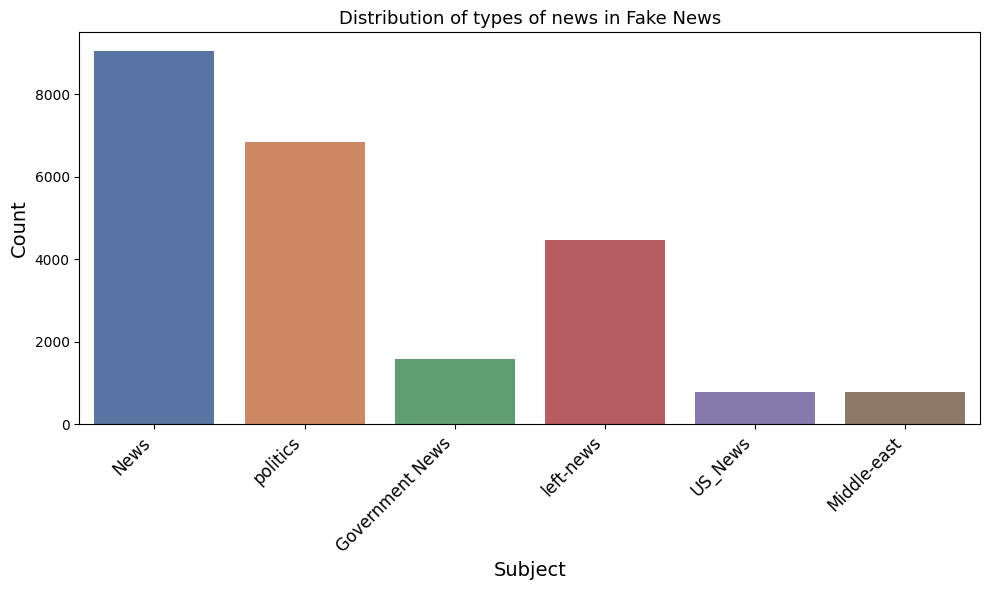

In [18]:
# Visualising the subject column
Fake_News = df_fake
plt.figure(figsize=(10, 6))
sns.countplot(x='subject', data = Fake_News, palette='deep')
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.xlabel('Subject', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('Distribution of types of news in Fake News', fontsize=13)
plt.tight_layout()  # to ensure proper spacing
plt.savefig("Fake_subjects.jpeg")
plt.show()

In [19]:
# date value count
df_fake.date.value_counts()

date
May 10, 2017                                                                                                                                             46
May 26, 2016                                                                                                                                             44
May 6, 2016                                                                                                                                              44
May 5, 2016                                                                                                                                              44
May 11, 2016                                                                                                                                             43
May 12, 2016                                                                                                                                             42
May 12, 2017                                               

## DATA PREPROCESSING

### Labelling FAKE = 1 and TRUE = 0

In [20]:
# Labelling TRUE = 0
df_true["label"] = 0
df_true.head()

,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",0
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",0
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",0
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",0
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",0


In [21]:
# Labelling FAKE = 1
df_fake["label"] = 1
df_fake.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",1
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",1
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",1
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",1
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",1


### Joining the datasets

In [22]:
# Combining Fake and True dataframes
df_news = pd.concat([df_fake, df_true], axis=0)
df_news.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",1
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",1
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",1
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",1
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",1


In [23]:
df_news.shape

(44898, 5)

### Shuffling the dataset

In [24]:
# Shuffling the dataset
df_news = df_news.sample(frac = 1, random_state = 2310246)
df_news.head()

,title,text,subject,date,label
2028,"FBI: After Blocking Trump’s Muslim Ban, Hawai...",After a federal court struck down the new vers...,News,"March 24, 2017",1
3683,Goldman's Donovan to withdraw from deputy Trea...,(Reuters) - Goldman Sachs Group Inc banker Jam...,politicsNews,"May 19, 2017",0
2628,Man whose firm was behind Trump dossier won't ...,WASHINGTON (Reuters) - The co-founder of the f...,politicsNews,"July 21, 2017",0
7808,How Trump rallies the faithful: Belittle Clint...,"CHARLOTTE, N.C. (Reuters) - Republican preside...",politicsNews,"October 15, 2016",0
1802,Republican attempt to deflect Trump-Russia pro...,(Reuters) - Republican lawmaker Devin Nunes’ i...,politicsNews,"September 11, 2017",0


### Removing duplicates

In [25]:
# number of duplicates present in title and text column
df_news[["title", "text"]].apply(lambda col : col.duplicated().sum())

title    6169
text     6252
dtype: int64

In [26]:
# Removing duplicates in the text column
df_news= df_news.drop_duplicates(subset=['text'], keep='last')
df_news[["title", "text"]].apply(lambda col : col.duplicated().sum())

title    376
text       0
dtype: int64

In [27]:
# duplicated value present in title column
title = df_news["title"]
df_news_dup = df_news[title.isin(title[title.duplicated()])].sort_values("title")
df_news_dup.head()

,title,text,subject,date,label
1535,McConnell Says He’ll Obstruct ANY Effort To H...,Siding with Trump s Attorney General Jeff Sess...,News,"May 10, 2017",1
1488,McConnell Says He’ll Obstruct ANY Effort To H...,Siding with Trump s Attorney General Jeff Sess...,News,"May 12, 2017",1
15031,'Can I get it to go?' Canada's Trudeau charms ...,MANILA (Reuters) - Canadian Prime Minister Jus...,worldnews,"November 12, 2017",0
674,'Can I get it to go?' Canada's Trudeau charms ...,MANILA (Reuters) - Canadian Prime Minister Jus...,politicsNews,"November 12, 2017",0
12126,'Fierce and formidable' Dlamini-Zuma eyes Sout...,JOHANNESBURG (Reuters) - Nkosazana Dlamini-Zum...,worldnews,"December 16, 2017",0


In [28]:
#removing the duplicates in the title column
df_news= df_news.drop_duplicates(subset=['title'], keep='last')
df_news[["title", "text"]].apply(lambda col : col.duplicated().sum())

title    0
text     0
dtype: int64

### Date formatting

In [29]:
# remove sentences and hyperlinks

# Define a pattern to search for month abbreviations
pattern = "Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec"

# Loop over each index in the range of the length of the 'date' column
for index in range(0,len(df_news.date)):

    # Search for the pattern in the string representation of the date at the current index
    match_date = re.search(pattern, str(df_news.date.iloc[index]))

    # Check if a match is found
    if match_date != None:
        # If a match is found, keep the original date value
        df_news.date.iloc[index] = df_news.date.iloc[index]
    else:
        # If no match is found, set the date value to "WRONG"
        df_news.date.iloc[index] = "WRONG"

# Display the count of unique values in the 'date' column
df_news.date.value_counts()

Streaming output truncated to the last 5000 lines.
<ipython-input-29-1363949c083e>:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_news.date.iloc[index] = df_news.date.iloc[index]
<ipython-input-29-1363949c083e>:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_news.date.iloc[index] = df_news.date.iloc[index]
<ipython-input-29-1363949c083e>:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_news.date.iloc[index] = df_news.dat

date
December 6, 2017       165
November 30, 2017      151
September 6, 2017      150
September 7, 2017      147
September 21, 2017     141
October 19, 2017       141
November 9, 2017       139
September 15, 2017     139
December 7, 2017       139
October 16, 2017       138
September 12, 2017     138
October 18, 2017       137
October 26, 2017       136
October 24, 2017       134
October 12, 2017       134
September 26, 2017     132
October 25, 2017       131
September 22, 2017     131
November 29, 2017      130
November 8, 2017       130
December 8, 2017       130
December 14, 2017      130
October 13, 2017       129
September 14, 2017     128
December 5, 2017       126
November 28, 2017      125
November 1, 2017       125
December 13, 2017      124
November 24, 2017      123
November 17, 2017      123
September 28, 2017     123
September 13, 2017     123
November 21, 2017      122
November 15, 2017      122
December 19, 2017      122
September 5, 2017      122
November 2, 2017       

In [30]:
# Filter the DataFrame to exclude rows where the date is "WRONG"
df_news = df_news[df_news.date != "WRONG"]

df_news.shape

(38264, 5)

In [31]:
# Formatting the date to a specific format

# Loop over each index in the range of the length of the 'date' column
for i in range (0, len(df_news.date)):

    # Get the date value at the current index
    input = df_news.date.iloc[i]

    # Convert the date string to a datetime object
    convert_date = pd.to_datetime(input)

    # Format the datetime object to a string in the format "Month day, Year"
    df_news.date.iloc[i]  = convert_date.strftime("%B %d, %Y")

# Display the updated 'date' column of the DataFrame
df_news.date

Streaming output truncated to the last 5000 lines.
<ipython-input-31-213a704e361d>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_news.date.iloc[i]  = convert_date.strftime("%B %d, %Y")
<ipython-input-31-213a704e361d>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_news.date.iloc[i]  = convert_date.strftime("%B %d, %Y")
<ipython-input-31-213a704e361d>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_news.date.iloc[i]  = 

2028         March 24, 2017
3683           May 19, 2017
2628          July 21, 2017
7808       October 15, 2016
1802     September 11, 2017
15152    September 28, 2015
12054     December 17, 2017
14649     November 16, 2017
15956     November 01, 2017
15499         July 07, 2015
15089     November 11, 2017
5788      February 01, 2017
3330      December 20, 2016
16090      October 30, 2017
19125    September 25, 2017
18223      October 05, 2017
17786      October 10, 2017
9099      December 29, 2017
5811      February 01, 2017
7039         April 07, 2016
6748         April 23, 2016
1124       October 20, 2017
14712      January 03, 2016
13328     December 01, 2017
19374    September 22, 2017
15375     November 08, 2017
8830       January 11, 2016
891       November 02, 2017
10670         June 08, 2017
14844     November 14, 2017
7091      November 23, 2016
3523      December 07, 2016
20691    September 07, 2017
12025     December 18, 2017
1757     September 21, 2017
6778      December 1

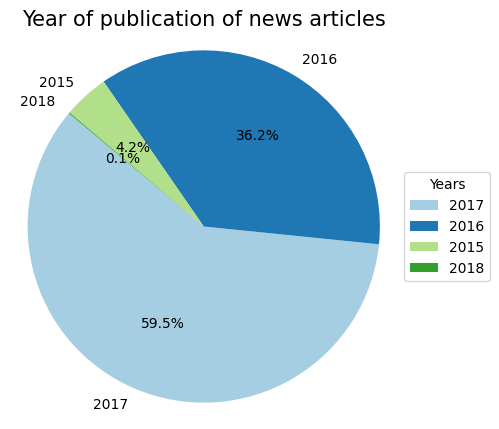

In [32]:
# Visualising the date column with respect to year

# Extract the year from the datetime objects and count occurrences of each year
year_count = pd.to_datetime(df_news['date']).dt.year.value_counts()

plt.figure(figsize=(5,5))
colors = plt.cm.Paired.colors
plt.pie(year_count, labels=year_count.index, autopct='%1.1f%%', startangle=140, colors=colors, textprops={'fontsize': 10})
plt.legend(year_count.index, title='Years', loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10)
plt.axis('equal')
plt.title('Year of publication of news articles', fontsize=15)
plt.savefig("news_dates.jpeg", dpi=300, bbox_inches='tight')
plt.show()

### Renaming subject column values

In [33]:
# Subject value count
df_news.subject.value_counts()

subject
politicsNews       11001
worldnews           9819
News                9049
politics            4325
left-news           2394
Government News      893
Middle-east          415
US_News              368
Name: count, dtype: int64

In [34]:
# Renaming the subject category
df_news.subject.replace({"News" : "worldnews", "politics": "politicsNews" }, inplace = True)

In [35]:
# Subject value count after renaming
df_news.subject.value_counts()

subject
worldnews          18868
politicsNews       15326
left-news           2394
Government News      893
Middle-east          415
US_News              368
Name: count, dtype: int64

### Feature encoding

In [36]:
# Create dummy variables for the 'subject' column
dummies = pd.get_dummies(df_news['subject'], prefix="subject", drop_first=True)

# Concatenate the dummy variables to the original DataFrame
df_news = pd.concat([df_news, dummies], axis=1)
df_news.head()

,title,text,subject,date,label,subject_Middle-east,subject_US_News,subject_left-news,subject_politicsNews,subject_worldnews
2028,"FBI: After Blocking Trump’s Muslim Ban, Hawai...",After a federal court struck down the new vers...,worldnews,"March 24, 2017",1,False,False,False,False,True
3683,Goldman's Donovan to withdraw from deputy Trea...,(Reuters) - Goldman Sachs Group Inc banker Jam...,politicsNews,"May 19, 2017",0,False,False,False,True,False
2628,Man whose firm was behind Trump dossier won't ...,WASHINGTON (Reuters) - The co-founder of the f...,politicsNews,"July 21, 2017",0,False,False,False,True,False
7808,How Trump rallies the faithful: Belittle Clint...,"CHARLOTTE, N.C. (Reuters) - Republican preside...",politicsNews,"October 15, 2016",0,False,False,False,True,False
1802,Republican attempt to deflect Trump-Russia pro...,(Reuters) - Republican lawmaker Devin Nunes’ i...,politicsNews,"September 11, 2017",0,False,False,False,True,False


## TEXT PREPROCESSING

### Changing to lower case

In [37]:
# Converting text to lower case
df_news['text_lowercase'] = df_news["text"].str.lower()
df_news.head()

,title,text,subject,date,label,subject_Middle-east,subject_US_News,subject_left-news,subject_politicsNews,subject_worldnews,text_lowercase
2028,"FBI: After Blocking Trump’s Muslim Ban, Hawai...",After a federal court struck down the new vers...,worldnews,"March 24, 2017",1,False,False,False,False,True,after a federal court struck down the new vers...
3683,Goldman's Donovan to withdraw from deputy Trea...,(Reuters) - Goldman Sachs Group Inc banker Jam...,politicsNews,"May 19, 2017",0,False,False,False,True,False,(reuters) - goldman sachs group inc banker jam...
2628,Man whose firm was behind Trump dossier won't ...,WASHINGTON (Reuters) - The co-founder of the f...,politicsNews,"July 21, 2017",0,False,False,False,True,False,washington (reuters) - the co-founder of the f...
7808,How Trump rallies the faithful: Belittle Clint...,"CHARLOTTE, N.C. (Reuters) - Republican preside...",politicsNews,"October 15, 2016",0,False,False,False,True,False,"charlotte, n.c. (reuters) - republican preside..."
1802,Republican attempt to deflect Trump-Russia pro...,(Reuters) - Republican lawmaker Devin Nunes’ i...,politicsNews,"September 11, 2017",0,False,False,False,True,False,(reuters) - republican lawmaker devin nunes’ i...


### Punctuation removal

In [38]:
def punctuation_removal (text):
    text = re.sub('https?://\S+|www\.\S+', '', text) # Remove URLs starting with http, https, or www
    text = re.sub('<.*?>+', '', text) # Remove HTML tags
    text = re.sub('\[.*?\]', '', text) # Remove text within square brackets
    text = re.sub("\\W"," ",text) # Replace non-word characters (everything except numbers and letters) with a space
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text) # Remove punctuation
    text = re.sub('\n', '', text) # Remove newline characters
    text = re.sub('\w*\d\w*', '', text) # Remove words containing numbers
    return text

In [39]:
df_news['text_punc'] = df_news['text_lowercase'].apply(lambda x: punctuation_removal(x))
df_news.head()

,title,text,subject,date,label,subject_Middle-east,subject_US_News,subject_left-news,subject_politicsNews,subject_worldnews,text_lowercase,text_punc
2028,"FBI: After Blocking Trump’s Muslim Ban, Hawai...",After a federal court struck down the new vers...,worldnews,"March 24, 2017",1,False,False,False,False,True,after a federal court struck down the new vers...,after a federal court struck down the new vers...
3683,Goldman's Donovan to withdraw from deputy Trea...,(Reuters) - Goldman Sachs Group Inc banker Jam...,politicsNews,"May 19, 2017",0,False,False,False,True,False,(reuters) - goldman sachs group inc banker jam...,reuters goldman sachs group inc banker jam...
2628,Man whose firm was behind Trump dossier won't ...,WASHINGTON (Reuters) - The co-founder of the f...,politicsNews,"July 21, 2017",0,False,False,False,True,False,washington (reuters) - the co-founder of the f...,washington reuters the co founder of the f...
7808,How Trump rallies the faithful: Belittle Clint...,"CHARLOTTE, N.C. (Reuters) - Republican preside...",politicsNews,"October 15, 2016",0,False,False,False,True,False,"charlotte, n.c. (reuters) - republican preside...",charlotte n c reuters republican preside...
1802,Republican attempt to deflect Trump-Russia pro...,(Reuters) - Republican lawmaker Devin Nunes’ i...,politicsNews,"September 11, 2017",0,False,False,False,True,False,(reuters) - republican lawmaker devin nunes’ i...,reuters republican lawmaker devin nunes i...


### Stopwords removal

In [40]:
# List of stopwords
print(stopwords.words('english'))

['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're", "you've", "you'll", "you'd", 'your', 'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', "she's", 'her', 'hers', 'herself', 'it', "it's", 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves', 'what', 'which', 'who', 'whom', 'this', 'that', "that'll", 'these', 'those', 'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do', 'does', 'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until', 'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into', 'through', 'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once', 'here', 'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more', 'most', 'other', 'some', 'such', 'no', 'nor', 'not', 'only', 'own', 'same', 'so', 'than', '

In [41]:
# delete duplicates using set function
StopWords = set(stopwords.words('english'))
def discard_stopwords(text):
    return " ".join([word for word in text.split() if word not in StopWords])

In [42]:
df_news['text_stopwords'] = df_news['text_punc'].apply( lambda x: discard_stopwords(x))
df_news.head()

,title,text,subject,date,label,subject_Middle-east,subject_US_News,subject_left-news,subject_politicsNews,subject_worldnews,text_lowercase,text_punc,text_stopwords
2028,"FBI: After Blocking Trump’s Muslim Ban, Hawai...",After a federal court struck down the new vers...,worldnews,"March 24, 2017",1,False,False,False,False,True,after a federal court struck down the new vers...,after a federal court struck down the new vers...,federal court struck new version muslim ban ba...
3683,Goldman's Donovan to withdraw from deputy Trea...,(Reuters) - Goldman Sachs Group Inc banker Jam...,politicsNews,"May 19, 2017",0,False,False,False,True,False,(reuters) - goldman sachs group inc banker jam...,reuters goldman sachs group inc banker jam...,reuters goldman sachs group inc banker james d...
2628,Man whose firm was behind Trump dossier won't ...,WASHINGTON (Reuters) - The co-founder of the f...,politicsNews,"July 21, 2017",0,False,False,False,True,False,washington (reuters) - the co-founder of the f...,washington reuters the co founder of the f...,washington reuters co founder firm commissione...
7808,How Trump rallies the faithful: Belittle Clint...,"CHARLOTTE, N.C. (Reuters) - Republican preside...",politicsNews,"October 15, 2016",0,False,False,False,True,False,"charlotte, n.c. (reuters) - republican preside...",charlotte n c reuters republican preside...,charlotte n c reuters republican presidential ...
1802,Republican attempt to deflect Trump-Russia pro...,(Reuters) - Republican lawmaker Devin Nunes’ i...,politicsNews,"September 11, 2017",0,False,False,False,True,False,(reuters) - republican lawmaker devin nunes’ i...,reuters republican lawmaker devin nunes i...,reuters republican lawmaker devin nunes invest...


### Frequent words removal

In [43]:
# Initialize a Counter object to store word counts
WordCount = Counter()
# Loop through each text entry in the 'text_stopwords' column of the DataFrame
for text in df_news['text_stopwords']:
     # Split the text into individual words and count each word
     for word in text.split():
        WordCount[word] += 1

# Get the 200 most common words and their counts
WordCount.most_common(200)

[('said', 120761),
 ('trump', 120271),
 ('would', 48859),
 ('u', 48465),
 ('president', 47776),
 ('people', 36006),
 ('one', 31875),
 ('state', 29828),
 ('reuters', 28411),
 ('also', 26801),
 ('new', 26766),
 ('donald', 25365),
 ('government', 24486),
 ('house', 24465),
 ('republican', 23538),
 ('states', 23384),
 ('clinton', 22840),
 ('obama', 22488),
 ('year', 21726),
 ('could', 21020),
 ('united', 20605),
 ('told', 20367),
 ('white', 19477),
 ('campaign', 19100),
 ('like', 18897),
 ('two', 18849),
 ('election', 18726),
 ('party', 18486),
 ('last', 18407),
 ('time', 17918),
 ('washington', 16316),
 ('first', 16223),
 ('news', 15991),
 ('country', 15683),
 ('even', 15138),
 ('former', 15117),
 ('years', 14175),
 ('many', 13960),
 ('security', 13591),
 ('law', 13430),
 ('say', 13361),
 ('republicans', 13354),
 ('percent', 13305),
 ('may', 13259),
 ('court', 13173),
 ('made', 13069),
 ('national', 12979),
 ('since', 12874),
 ('american', 12856),
 ('right', 12726),
 ('political', 12696),

In [44]:
# Removing manually selected list of frequently occurring words
frequently_occuring_words = ("said","U","would","one","also","new","house","like","two","last","time","first","even","many","say","may","made","since","get","make","us","way","know","think","take","well","day","see","says","go","three","com","old","end","top")

def discard_frequent_words(text):
    return " ".join([word for word in text. split() if word not in frequently_occuring_words])

In [45]:
df_news['text_frequent'] = df_news['text_stopwords'].apply( lambda x: discard_frequent_words(x))
df_news.head()

,title,text,subject,date,label,subject_Middle-east,subject_US_News,subject_left-news,subject_politicsNews,subject_worldnews,text_lowercase,text_punc,text_stopwords,text_frequent
2028,"FBI: After Blocking Trump’s Muslim Ban, Hawai...",After a federal court struck down the new vers...,worldnews,"March 24, 2017",1,False,False,False,False,True,after a federal court struck down the new vers...,after a federal court struck down the new vers...,federal court struck new version muslim ban ba...,federal court struck version muslim ban basica...
3683,Goldman's Donovan to withdraw from deputy Trea...,(Reuters) - Goldman Sachs Group Inc banker Jam...,politicsNews,"May 19, 2017",0,False,False,False,True,False,(reuters) - goldman sachs group inc banker jam...,reuters goldman sachs group inc banker jam...,reuters goldman sachs group inc banker james d...,reuters goldman sachs group inc banker james d...
2628,Man whose firm was behind Trump dossier won't ...,WASHINGTON (Reuters) - The co-founder of the f...,politicsNews,"July 21, 2017",0,False,False,False,True,False,washington (reuters) - the co-founder of the f...,washington reuters the co founder of the f...,washington reuters co founder firm commissione...,washington reuters co founder firm commissione...
7808,How Trump rallies the faithful: Belittle Clint...,"CHARLOTTE, N.C. (Reuters) - Republican preside...",politicsNews,"October 15, 2016",0,False,False,False,True,False,"charlotte, n.c. (reuters) - republican preside...",charlotte n c reuters republican preside...,charlotte n c reuters republican presidential ...,charlotte n c reuters republican presidential ...
1802,Republican attempt to deflect Trump-Russia pro...,(Reuters) - Republican lawmaker Devin Nunes’ i...,politicsNews,"September 11, 2017",0,False,False,False,True,False,(reuters) - republican lawmaker devin nunes’ i...,reuters republican lawmaker devin nunes i...,reuters republican lawmaker devin nunes invest...,reuters republican lawmaker devin nunes invest...


### Rare words removal

In [46]:
# Create a set of words that are considered rare based on their word count
rare_words = set(word for (word, wc) in WordCount.most_common() if wc <= 150)
rare_words

{'wales',
 'marshes',
 'fallfashion',
 'sulaimaniya',
 'sirajuddin',
 'privateers',
 'mirthful',
 'metastasize',
 'coun',
 'lefebvre',
 'reeves',
 'inanimate',
 'yulee',
 'scratches',
 'forceps',
 'mouaz',
 'repercussions',
 'eximbank',
 'loveeegabby',
 'hedgeupdate',
 'chantie',
 'awas',
 'spellng',
 'morgs',
 'canteen',
 'vernal',
 'adolescence',
 'tiafoe',
 'swane',
 'demonize',
 'boualem',
 'ogilvy',
 'spcomsteel',
 'kilmurray',
 'overhear',
 'doi',
 'electnehlen',
 'mincey',
 'immolation',
 'sneak',
 'xiaofeng',
 'decentralized',
 'easybakedoven',
 'tongotongo',
 'alberghini',
 'solomonster',
 'zuwara',
 'evangelists',
 'bowed',
 'protagonists',
 'sloshed',
 'jousted',
 'maddest',
 'outwards',
 'karol',
 'stamford',
 'tabasco',
 'usurps',
 'naples',
 'remaking',
 'brewmaster',
 'independentdespite',
 'steamy',
 'gefilde',
 'makati',
 'gerrit',
 'szamboti',
 'unsparing',
 'relevancythanks',
 'prausner',
 'summersharp',
 'comprising',
 'ulyanov',
 'indexof',
 'assassinates',
 'pretr

In [47]:
# function to discard rare words
def discard_rare(text):
    return " ".join([word for word in text.split() if word not in rare_words])

In [48]:
df_news['text_rare'] = df_news['text_frequent'].apply( lambda x: discard_rare(x))
df_news.head()

,title,text,subject,date,label,subject_Middle-east,subject_US_News,subject_left-news,subject_politicsNews,subject_worldnews,text_lowercase,text_punc,text_stopwords,text_frequent,text_rare
2028,"FBI: After Blocking Trump’s Muslim Ban, Hawai...",After a federal court struck down the new vers...,worldnews,"March 24, 2017",1,False,False,False,False,True,after a federal court struck down the new vers...,after a federal court struck down the new vers...,federal court struck new version muslim ban ba...,federal court struck version muslim ban basica...,federal court struck version muslim ban basica...
3683,Goldman's Donovan to withdraw from deputy Trea...,(Reuters) - Goldman Sachs Group Inc banker Jam...,politicsNews,"May 19, 2017",0,False,False,False,True,False,(reuters) - goldman sachs group inc banker jam...,reuters goldman sachs group inc banker jam...,reuters goldman sachs group inc banker james d...,reuters goldman sachs group inc banker james d...,reuters goldman sachs group inc banker james n...
2628,Man whose firm was behind Trump dossier won't ...,WASHINGTON (Reuters) - The co-founder of the f...,politicsNews,"July 21, 2017",0,False,False,False,True,False,washington (reuters) - the co-founder of the f...,washington reuters the co founder of the f...,washington reuters co founder firm commissione...,washington reuters co founder firm commissione...,washington reuters co founder firm dossier don...
7808,How Trump rallies the faithful: Belittle Clint...,"CHARLOTTE, N.C. (Reuters) - Republican preside...",politicsNews,"October 15, 2016",0,False,False,False,True,False,"charlotte, n.c. (reuters) - republican preside...",charlotte n c reuters republican preside...,charlotte n c reuters republican presidential ...,charlotte n c reuters republican presidential ...,charlotte n c reuters republican presidential ...
1802,Republican attempt to deflect Trump-Russia pro...,(Reuters) - Republican lawmaker Devin Nunes’ i...,politicsNews,"September 11, 2017",0,False,False,False,True,False,(reuters) - republican lawmaker devin nunes’ i...,reuters republican lawmaker devin nunes i...,reuters republican lawmaker devin nunes invest...,reuters republican lawmaker devin nunes invest...,reuters republican lawmaker devin nunes invest...


### Stemming

In [49]:
# Initialize a PorterStemmer object
stemmer = PorterStemmer()

# Define a function to stem words in a given text
def stemming_text(text):
    words = text.split()
    stem_words = [stemmer.stem(word) for word in words]
    return " ".join(stem_words)

# Apply the stemming_text function to the 'text_rare' column
df_news['text_stemming'] = df_news['text_rare'].apply(stemming_text)
df_news.head()

,title,text,subject,date,label,subject_Middle-east,subject_US_News,subject_left-news,subject_politicsNews,subject_worldnews,text_lowercase,text_punc,text_stopwords,text_frequent,text_rare,text_stemming
2028,"FBI: After Blocking Trump’s Muslim Ban, Hawai...",After a federal court struck down the new vers...,worldnews,"March 24, 2017",1,False,False,False,False,True,after a federal court struck down the new vers...,after a federal court struck down the new vers...,federal court struck new version muslim ban ba...,federal court struck version muslim ban basica...,federal court struck version muslim ban basica...,feder court struck version muslim ban basic do...
3683,Goldman's Donovan to withdraw from deputy Trea...,(Reuters) - Goldman Sachs Group Inc banker Jam...,politicsNews,"May 19, 2017",0,False,False,False,True,False,(reuters) - goldman sachs group inc banker jam...,reuters goldman sachs group inc banker jam...,reuters goldman sachs group inc banker james d...,reuters goldman sachs group inc banker james d...,reuters goldman sachs group inc banker james n...,reuter goldman sach group inc banker jame nomi...
2628,Man whose firm was behind Trump dossier won't ...,WASHINGTON (Reuters) - The co-founder of the f...,politicsNews,"July 21, 2017",0,False,False,False,True,False,washington (reuters) - the co-founder of the f...,washington reuters the co founder of the f...,washington reuters co founder firm commissione...,washington reuters co founder firm commissione...,washington reuters co founder firm dossier don...,washington reuter co founder firm dossier dona...
7808,How Trump rallies the faithful: Belittle Clint...,"CHARLOTTE, N.C. (Reuters) - Republican preside...",politicsNews,"October 15, 2016",0,False,False,False,True,False,"charlotte, n.c. (reuters) - republican preside...",charlotte n c reuters republican preside...,charlotte n c reuters republican presidential ...,charlotte n c reuters republican presidential ...,charlotte n c reuters republican presidential ...,charlott n c reuter republican presidenti nomi...
1802,Republican attempt to deflect Trump-Russia pro...,(Reuters) - Republican lawmaker Devin Nunes’ i...,politicsNews,"September 11, 2017",0,False,False,False,True,False,(reuters) - republican lawmaker devin nunes’ i...,reuters republican lawmaker devin nunes i...,reuters republican lawmaker devin nunes invest...,reuters republican lawmaker devin nunes invest...,reuters republican lawmaker devin nunes invest...,reuter republican lawmak devin nune investig w...


In [50]:
# Combine all text into a single string
text_all = ' '.join(df_news['text_rare'])

# Tokenize the combined text into individual words
my_tokens = nltk.word_tokenize(text_all)

In [51]:
# word count
token_count = len(my_tokens)
token_count

7172363

In [52]:
# unique word count
uniq_words = len(list(set(my_tokens)))
uniq_words

6821

## TOKENIZATION

In [53]:
# Initialize a variable to store the maximum length of tokenized documents
a = -1

# Iterate over each document
for doc in df_news.text_stemming:
  token = nltk.word_tokenize(doc)
  if len(token) > a:
    max_length = len(token)

print("max number of words in a sentence:", max_length)

max number of words in a sentence: 430


In [54]:
# train test split
x_train,x_test,y_train,y_test = train_test_split(df_news.text_stemming, df_news.label, test_size=0.2)

In [55]:
# Initialize a Tokenizer object with a specified number of unique words to keep
tokenizer = Tokenizer(num_words=uniq_words)

# Fit the tokenizer on the training texts to build the word index
tokenizer.fit_on_texts(x_train)

# Convert the training texts to sequences of integers
train_seq = tokenizer.texts_to_sequences(x_train)

# Convert the testing texts to sequences of integers
test_seq = tokenizer.texts_to_sequences(x_test)

In [56]:
# training sequence
print(train_seq[0])

[568, 8, 1407, 112, 1029, 1735, 10, 143, 20, 2, 955, 5, 592, 1574, 11, 1, 59, 15, 1431, 1355, 3517, 63, 1407, 3986, 2591, 35, 49, 143, 3, 1170, 454, 38, 934, 2105, 202, 2, 39, 1407, 197, 247, 204, 1243, 264, 30, 875, 2453, 475, 1170, 454, 875, 3099, 1662, 1407, 312, 3677, 3160, 26, 13, 143, 78, 1185, 1169, 1120, 15, 12, 21, 204, 68, 88, 454, 350, 163, 441, 10, 438, 20, 2, 934, 47, 454, 1460, 934, 282, 1974, 1779, 545, 202, 2, 311, 2453, 15, 1892, 185, 1729, 454, 1520, 1847, 218, 827, 63, 1421, 679, 63, 1490, 3106, 82, 10, 23, 3160, 683, 3130, 1591, 4, 913, 404, 726, 201, 18, 1407, 424, 347, 1, 454, 1, 1107, 131, 369, 5, 592, 1574, 785, 298, 2025, 1407, 34, 625, 197, 466, 93, 2, 778, 1265, 191, 1498, 1407, 86, 419, 87, 257, 1, 68, 88, 438, 77, 63, 2311, 2, 778, 1355, 251, 93, 1857, 23, 88, 533, 1858, 127, 1754, 64, 63, 20, 2, 177, 63, 780, 23, 247, 395, 202, 2, 395, 1159, 38, 1572, 39, 566, 3, 2315, 294, 1175, 568, 341, 1175, 332, 211, 614, 202, 2, 684, 354, 14, 42]


In [57]:
# length of training sequence
len(train_seq)

30611

In [58]:
# test sequence
print(test_seq[0])

[99, 34, 814, 27, 35, 2168, 352, 476, 11, 1, 828, 23, 1206, 157, 97, 220, 166, 1999, 352, 476, 7, 352, 476, 66, 2185, 444, 86, 66, 275, 352, 476, 365, 912, 352, 476, 396, 2914, 320, 66, 62, 352, 476, 245, 3981, 393, 3366, 479, 282, 62, 1130, 479, 212, 331, 365, 912, 331, 2583, 418, 581, 212, 131, 2131, 479, 270, 1418, 862, 132, 227, 418, 120, 163, 10, 623, 753, 28, 55, 966, 777, 1827, 47, 1103, 519, 155, 818, 3603, 19, 40, 860, 3824, 1796, 212, 11, 1, 181, 1136, 297, 62, 2806, 138, 656, 814, 7, 1130, 2027, 413, 248, 62, 1, 727, 1989, 1, 54, 33, 774, 2929, 1678, 352, 476, 417, 1418, 200, 1891, 256, 330, 2131, 666, 50, 131, 4021, 1184, 1431, 1, 727, 479, 363, 413, 117, 6, 194, 3306, 1, 457, 158, 955, 418, 1481, 20, 2, 1030, 385, 1973, 418, 253, 375, 337, 200, 27, 1184, 682, 200, 1418, 418, 217, 1045, 1623, 331, 1033, 13, 2929, 1678, 340, 1418, 418, 200, 1324, 132, 1083, 200, 27, 3973, 363, 1095, 236, 227, 395, 1045, 3175, 1409, 72, 3170, 4274, 1390, 1732, 418, 609, 817, 4441, 851, 1233, 

In [59]:
# length of test sequence
len(test_seq)

7653

## PADDING

In [60]:
# Print the first document and its corresponding encoded sequence
print('Encoding for doc:\n', df_news.text_stemming[0], '\n is :', train_seq[0])

Encoding for doc:
 0    donald trump wish american happi year leav ins...
0    washington reuter head conserv republican fact...
Name: text_stemming, dtype: object 
 is : [568, 8, 1407, 112, 1029, 1735, 10, 143, 20, 2, 955, 5, 592, 1574, 11, 1, 59, 15, 1431, 1355, 3517, 63, 1407, 3986, 2591, 35, 49, 143, 3, 1170, 454, 38, 934, 2105, 202, 2, 39, 1407, 197, 247, 204, 1243, 264, 30, 875, 2453, 475, 1170, 454, 875, 3099, 1662, 1407, 312, 3677, 3160, 26, 13, 143, 78, 1185, 1169, 1120, 15, 12, 21, 204, 68, 88, 454, 350, 163, 441, 10, 438, 20, 2, 934, 47, 454, 1460, 934, 282, 1974, 1779, 545, 202, 2, 311, 2453, 15, 1892, 185, 1729, 454, 1520, 1847, 218, 827, 63, 1421, 679, 63, 1490, 3106, 82, 10, 23, 3160, 683, 3130, 1591, 4, 913, 404, 726, 201, 18, 1407, 424, 347, 1, 454, 1, 1107, 131, 369, 5, 592, 1574, 785, 298, 2025, 1407, 34, 625, 197, 466, 93, 2, 778, 1265, 191, 1498, 1407, 86, 419, 87, 257, 1, 68, 88, 438, 77, 63, 2311, 2, 778, 1355, 251, 93, 1857, 23, 88, 533, 1858, 127, 1754, 64, 63,

In [61]:
# padding
train_padding = pad_sequences(train_seq, maxlen=5000, padding='post', truncating='post')
test_padding = pad_sequences(test_seq, maxlen=5000, padding='post', truncating='post')

for i,doc in enumerate(train_padding[:2]):
  print('Padded encoding for documents: ', i+1, "is:", doc)

Padded encoding for documents:  1 is: [ 568    8 1407  112 1029 1735   10  143   20    2  955    5  592 1574
   11    1   59   15 1431 1355 3517   63 1407 3986 2591   35   49  143
    3 1170  454   38  934 2105  202    2   39 1407  197  247  204 1243
  264   30  875 2453  475 1170  454  875 3099 1662 1407  312 3677 3160
   26   13  143   78 1185 1169 1120   15   12   21  204   68   88  454
  350  163  441   10  438   20    2  934   47  454 1460  934  282 1974
 1779  545  202    2  311 2453   15 1892  185 1729  454 1520 1847  218
  827   63 1421  679   63 1490 3106   82   10   23 3160  683 3130 1591
    4  913  404  726  201   18 1407  424  347    1  454    1 1107  131
  369    5  592 1574  785  298 2025 1407   34  625  197  466   93    2
  778 1265  191 1498 1407   86  419   87  257    1   68   88  438   77
   63 2311    2  778 1355  251   93 1857   23   88  533 1858  127 1754
   64   63   20    2  177   63  780   23  247  395  202    2  395 1159
   38 1572   39  566    3 2315  294 117

## Research Q2

### BiLSTM

Word Embeddings and Model Building

In [62]:
# Initialize a sequential model
model = Sequential()
model.add(Embedding(input_dim=uniq_words, output_dim=120, input_length=5000))
model.add(Bidirectional(LSTM(120)))
model.add(Dense(120,activation='relu'))
model.add(Dense(1,activation='sigmoid'))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['acc'])
print(model.summary())

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 5000, 120)         818520    
                                                                 
 bidirectional (Bidirection  (None, 240)               231360    
 al)                                                             
                                                                 
 dense (Dense)               (None, 120)               28920     
                                                                 
 dense_1 (Dense)             (None, 1)                 121       
                                                                 
Total params: 1078921 (4.12 MB)
Trainable params: 1078921 (4.12 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
None


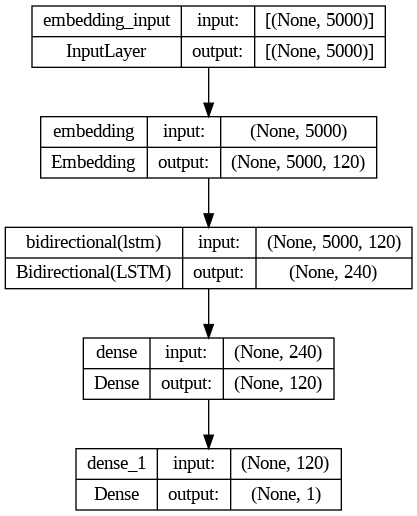

In [63]:
# plot BiLSTM model configuration
plot_model(model, to_file='bilstm_plot.png', show_shapes=True, show_layer_names=True)

In [64]:
# Convert to a NumPy array
y_train = np.asarray(y_train)
y_test = np.asarray(y_test)

model.fit(train_padding, y_train, batch_size=128, validation_data=(test_padding, y_test), epochs=1)

240/240 [==============================] - 155s 626ms/step - loss: 0.0667 - acc: 0.9783 - val_loss: 0.0042 - val_acc: 0.9995


In [65]:
# Make predictions on the test data using the trained model
p = model.predict(test_padding)

# Initialize an empty list to store the final binary predictions
modelprediction = []

# Iterate over the predicted probabilities
for i in range(len(p)):
  # If the predicted probability is greater than 0.5, classify as 1 (positive class)
  if p[i].item()>0.5:
    modelprediction.append(1)
  # If the predicted probability is 0.5 or less, classify as 0 (negative class)
  else:
    modelprediction.append(0)

240/240 [==============================] - 28s 114ms/step


Model Evaluation

In [66]:
# accuracy
bilstm_accuracy = accuracy_score(list(y_test), modelprediction)
print('Accuracy for BiLSTM Model :', bilstm_accuracy)

# F1 score
bilstm_score = f1_score(list(y_test), modelprediction, average='binary')
print('F-score for BiLSTM : %.3f' % bilstm_score)

# recall
bilstm_recall = recall_score(list(y_test), modelprediction, average='binary')
print('Recall for BiLSTM: %.3f' % bilstm_recall)

# precision
bilstm_precision = precision_score(list(y_test), modelprediction, average='binary')
print('Precision for BiLSTM: %.3f' % bilstm_precision)

Accuracy for BiLSTM Model : 0.9994773291519665
F-score for BiLSTM : 0.999
Recall for BiLSTM: 1.000
Precision for BiLSTM: 0.999


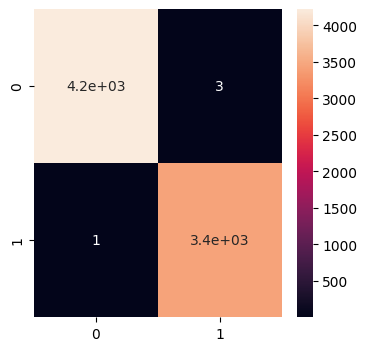

In [67]:
# confusion matrix
matrix = confusion_matrix(list(y_test), modelprediction)
plt.figure(figsize=(4,4))
sns.heatmap(matrix, annot=True)
plt.savefig("BiLSTM Confusion Matrix")